<a href="https://colab.research.google.com/github/alexmordashov/computer_math/blob/master/5.%20%D0%91%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B0%20Pandas.%20%D0%92%D0%B8%D0%B7%D1%83%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D0%B9%20%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%91%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B0_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №5. Библиотека Pandas. Визуальный анализ данных

## Комплексное задание №1. Применение основных методов для анализа данных

1. Скачайте этот блокнот к себе.
2. Заполните пропущенные ячейки, отвечая на заданные вопросы. Там должен быть код! (если не сказано обратное)
3. Сохраните результат в своём гитхаб репозитории.

#### Полезная литература
- [**Блокнот с теорией**](https://colab.research.google.com/drive/1SLqmaYz4xEsxVV-LGwb3ityheBTzHJQu?usp=sharing)
- http://pandas.pydata.org/pandas-docs/stable/10min.html
- https://pandas.pydata.org/pandas-docs/stable/indexing.html
- https://pandas.pydata.org/pandas-docs/stable/missing_data.html

В этом задании мы с Вами рассмотрим датасет [Adult Data Set](https://archive.ics.uci.edu/ml/datasets/Adult).
Основывается он на данных переписи населения 1994 года в США.

Расшифровка содержимого колонок:

- age: continuous.
- workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
- fnlwgt: continuous. sampling weight, more here: SIPP Weighting.
- education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
- education-num: continuous.
- marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- sex: Female, Male.
- capital-gain: continuous. Income from investment sources, apart from wages/salary.
- capital-loss: continuous. Losses from investment sources, apart from wages/salary.
- hours-per-week: continuous.
- native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

In [39]:
%matplotlib inline
import pandas as pd
import numpy as np
pd.__version__

'2.2.2'

Если вы увидели warning, не переживайте, всё хорошо.
- https://stackoverflow.com/questions/40845304/runtimewarning-numpy-dtype-size-changed-may-indicate-binary-incompatibility
- https://github.com/numpy/numpy/pull/432

In [92]:
columns='age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income'.split(',')
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', na_values=' ?', names=columns)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [93]:
df['workclass'] = df['workclass'].str.strip()
df['education'] = df['education'].str.strip()
df['marital.status'] = df['marital.status'].str.strip()
df['occupation'] = df['occupation'].str.strip()
df['relationship'] = df['relationship'].str.strip()
df['race'] = df['race'].str.strip()
df['sex'] = df['sex'].str.strip()
df['native.country'] = df['native.country'].str.strip()
df['income'] = df['income'].str.strip()

1) Выведите последние 10 элеметнов датасета

In [94]:
print(df.tail(10))

       age     workclass  fnlwgt     education  education.num  \
32551   32       Private   34066          10th              6   
32552   43       Private   84661     Assoc-voc             11   
32553   32       Private  116138       Masters             14   
32554   53       Private  321865       Masters             14   
32555   22       Private  310152  Some-college             10   
32556   27       Private  257302    Assoc-acdm             12   
32557   40       Private  154374       HS-grad              9   
32558   58       Private  151910       HS-grad              9   
32559   22       Private  201490       HS-grad              9   
32560   52  Self-emp-inc  287927       HS-grad              9   

           marital.status         occupation   relationship  \
32551  Married-civ-spouse  Handlers-cleaners        Husband   
32552  Married-civ-spouse              Sales        Husband   
32553       Never-married       Tech-support  Not-in-family   
32554  Married-civ-spouse    Exe

2) Сколько колонок и сколько строк в этом датасете?

In [95]:
print(f'В этом датасете {df.shape[0]} строк и {df.shape[1]} колонок')

В этом датасете 32561 строк и 15 колонок


3) Какие типы данных у элементов этого датасета?

In [96]:
print(df.dtypes)

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object


4) Какие признаки имеют пропуски?

In [97]:
print(df.isnull().any())

age               False
workclass          True
fnlwgt            False
education         False
education.num     False
marital.status    False
occupation         True
relationship      False
race              False
sex               False
capital.gain      False
capital.loss      False
hours.per.week    False
native.country     True
income            False
dtype: bool


5) Как вы думаете, с чем связаны пропуски этих значение. Напишите развернутый ответ в ячейке ниже.

Ваш ответ: Возможно, это ошибка в заполнение данных, связанная с невнимательностью заполняющего опросник. Также может быть, что среди опрашиваемых были безработные люди, которые не захотели отвечать на этот вопрос. А в native.country могут быть пропуски, например, если среди опрашиваемых были сироты, беженцы или нелегалы, скрывающие своё происхождение.

6) Какие и сколько различных рабочих классов workclass представлено в выборке?

In [98]:
print(df['workclass'].unique())
print(df['workclass'].nunique())

['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' nan
 'Self-emp-inc' 'Without-pay' 'Never-worked']
8


7) Какой средний возраст женщин и мужчин?

In [99]:
df.groupby('sex')['age'].mean()

,age
sex,
Female,36.858230
Male,39.433547


8) Постройте гистограмму(bar) распределения образования людей (education)

<Axes: xlabel='education'>

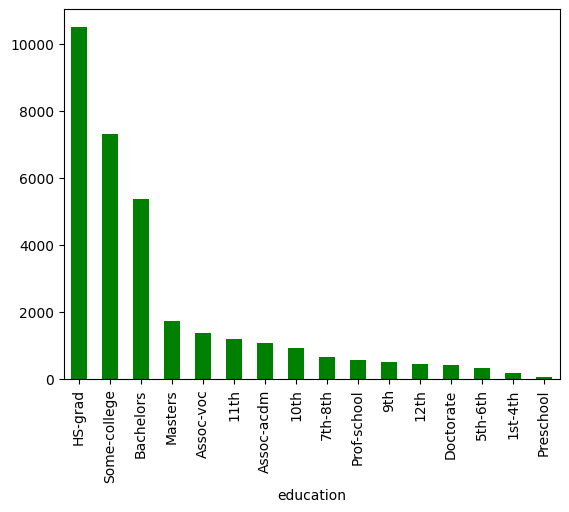

In [100]:
df['education'].value_counts().plot(kind='bar', color='green')

9) Каковы средние значения и среднеквадратичные отклонения возраста тех, кто получает более 50K в год (признак income) и тех, кто получает менее 50K в год?

In [101]:
df.groupby('income')['age'].agg(['mean', 'std'])

,mean,std
income,,
<=50K,36.783738,14.020088
>50K,44.249841,10.519028


10) Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? (признак education - Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters или Doctorate)

In [102]:
higher_education = ['Bachelors', 'Prof-school', 'Assoc-acdm', 'Assoc-voc', 'Masters', 'Doctorate']
high_income_df = df[df['income'] == ">50K"]
has_no_higher = ~high_income_df['education'].apply(lambda x: x in higher_education)
print(has_no_higher.value_counts())

education
False    4535
True     3306
Name: count, dtype: int64


11) Среди кого больше доля зарабатывающих много (>50K): среди женатых или холостых мужчин (признак marital-status)? Женатыми считаем тех, у кого marital-status начинается с Married (Married-civ-spouse, Married-spouse-absent или Married-AF-spouse), остальных считаем холостыми.

In [103]:
men = df[df['sex'] == 'Male'].copy()
men['married'] = men['marital.status'].str.startswith('Married')
result = men.groupby('married')['income'].value_counts(normalize=True)
print(result)

married  income
False    <=50K     0.915505
         >50K      0.084495
True     <=50K     0.559486
         >50K      0.440514
Name: proportion, dtype: float64


Можно сделать вывод, что женатых мужчин, которые зарабатывают больше 50к, больше, чем холостяков.

12) Постройте [сводную таблицу](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html) для отображения зависимостей среднего времени работы (hours.per.week) с доходом (income) для каждой страны (native.country).  


> Пример фрагмента таблицы:



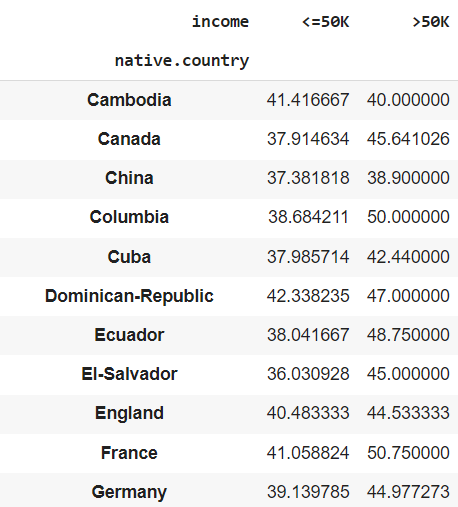

In [104]:
print(df.groupby(['native.country', 'income'])['hours.per.week'].mean().unstack())

income                          <=50K       >50K
native.country                                  
Cambodia                    41.416667  40.000000
Canada                      37.914634  45.641026
China                       37.381818  38.900000
Columbia                    38.684211  50.000000
Cuba                        37.985714  42.440000
Dominican-Republic          42.338235  47.000000
Ecuador                     38.041667  48.750000
El-Salvador                 36.030928  45.000000
England                     40.483333  44.533333
France                      41.058824  50.750000
Germany                     39.139785  44.977273
Greece                      41.809524  50.625000
Guatemala                   39.360656  36.666667
Haiti                       36.325000  42.750000
Holand-Netherlands          40.000000        NaN
Honduras                    34.333333  60.000000
Hong                        39.142857  45.000000
Hungary                     31.300000  50.000000
India               

13) Постройте сводную таблицу для сравнения уровня образования и разности между capital.gain и capital.loss по следующему алгоритму:&nbsp;  
1. Создайте вспомогательную таблицу (датафрейм) и добавьте в неё столбец "education" из целевой таблицы
2. Добавьте во вспомогательную таблицу ещё один столбец "capital.diff", значиниями которого будут являться разности столбцов capital.gain и capital.loss целевой таблицы
3. Удалите во вспомогательной таблице все строки, в которых значение столбца "capital.diff" равно нулю  
&nbsp; Подсказка:
```
summary_table = summary_table[summary_table['capital.diff'] != 0 ]
```
4. Для набора значений из столбца "capital.diff", необходимо сформировать 10 категорий (кластеров), это можно сделать с помощью математических функций, типа log, извлечение корня N-ой степени и округления, для последующего перехода к категориальным признакам.  
  * В нашем случае, можно воспользоваться методом [pd.qcut()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html) и равномерно разделить наш набор данных на целевое количество категорий
5. Добавьте во вспомогательную таблицу столбец "categories", и проинициализируйте его значениями категорий, которые возвращает метод pd.qcut()  
&nbsp; Пример:
```
summary_table['categories'] = pd.qcut(summary_table["capital.diff"], q = 10)

6. Постройте сводную таблицу с помощью метода pivot_table(),

Примерная структура таблицы (в качестве значений выводится количество людей, относящихся к той или иной группе):

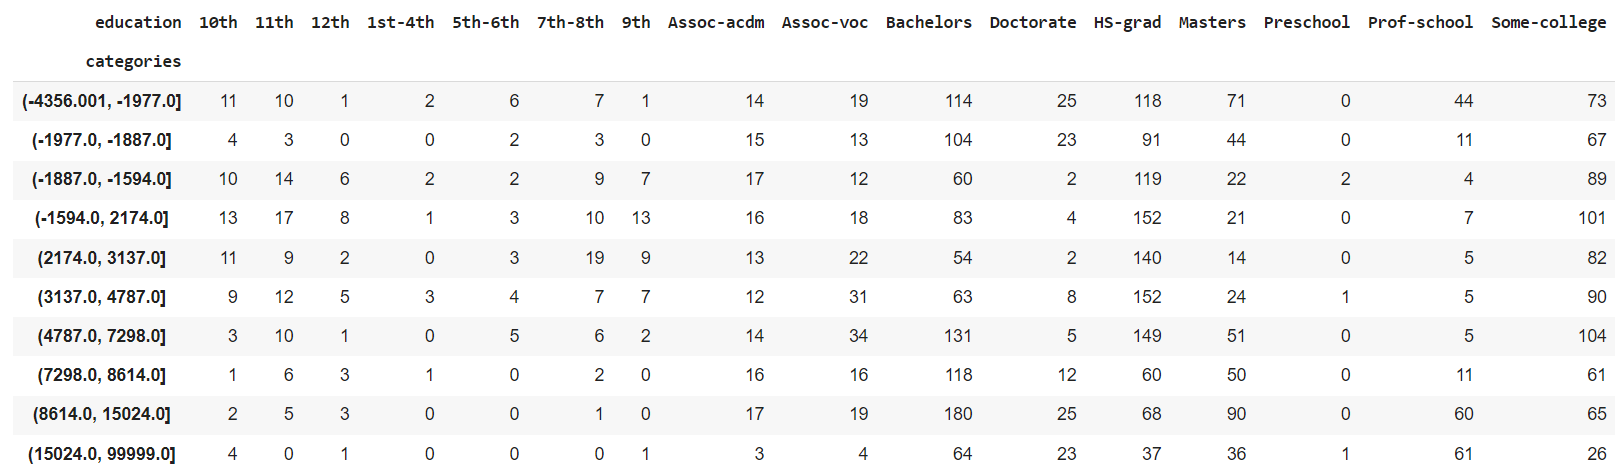

In [105]:
summary_table = df[['education']].copy()
summary_table['capital.diff'] = df['capital.gain'] - df['capital.loss']
summary_table = summary_table[summary_table['capital.diff'] != 0 ]
summary_table['categories'] = pd.qcut(summary_table['capital.diff'], q=10)
print(summary_table.groupby(['education', 'categories'])['capital.diff'].count())

education     categories          
10th          (-4356.001, -1977.0]     11
              (-1977.0, -1887.0]        4
              (-1887.0, -1594.0]       10
              (-1594.0, 2174.0]        13
              (2174.0, 3137.0]         11
                                     ... 
Some-college  (3137.0, 4787.0]         90
              (4787.0, 7298.0]        104
              (7298.0, 8614.0]         61
              (8614.0, 15024.0]        65
              (15024.0, 99999.0]       26
Name: capital.diff, Length: 160, dtype: int64


/tmp/ipykernel_17774/1084463048.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(summary_table.groupby(['education', 'categories'])['capital.diff'].count())


14) Женщины из каких стран получают в среднем большую зарплату (>50K) чаще.

In [63]:
women = df[df['sex'] == 'Female'].copy()
women = women.dropna(subset=['native.country'])
women['high_income'] = women['income'] == '>50K'
country_stats = women.groupby('native.country')['high_income'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(country_stats.head(10))

                    mean  count
native.country                 
Yugoslavia      0.333333      3
Taiwan          0.266667     15
France          0.250000     12
Iran            0.250000      8
Japan           0.250000     20
Italy           0.238095     21
China           0.238095     21
Canada          0.230769     39
Greece          0.200000      5
Scotland        0.200000      5


15) Создайте случайную колонку - magic_salary, которую нужно будет вычислить следующим образом: если зарплата небольшая (<50K), тогда случайно выберите число из диапазона [0,50]. Если зарплата выше 50K тогда из диапазона [51, 200]. Посчитайте среднюю зарплату в час для групп людей с одни уровнем образования на основе нашей случайной колонки magic_salary

In [70]:
def f(income_row):
    if income_row == '>50K':
        return np.random.randint(51, 201)
    else:
        return np.random.randint(0, 51)

df['magic_salary'] = df['income'].apply(f)
df['magic_salary_per_hour'] = df['magic_salary'] / df['hours.per.week']
res = df.groupby('education')['magic_salary_per_hour'].mean().sort_values(ascending=False)
print(res)

education
Doctorate       2.912938
Prof-school     2.236269
Masters         2.203731
Bachelors       1.691304
Assoc-acdm      1.500725
Assoc-voc       1.371543
Some-college    1.272348
11th            1.143461
HS-grad         1.126544
10th            1.097987
12th            1.050997
7th-8th         0.992412
9th             0.962272
5th-6th         0.868037
1st-4th         0.829348
Preschool       0.816589
Name: magic_salary_per_hour, dtype: float64


## Комплексное задание №2. Визуальный анализ данных. Часть 1

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

В этом задании Вам предлагается провести визуальный анализ датасета о прокатах велосипедов https://www.kaggle.com/c/bike-sharing-demand/data. Оригинальная задача предполагает построение модели предсказания количества прокатов в городе в зависимости от погоды.

Для каждого дня проката известны следующие признаки (как они были указаны в источнике данных):
- season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
- yr: 0 - 2011, 1 - 2012
- mnth: от 1 до 12
- holiday: 0 - нет праздника, 1 - есть праздник
- weekday: от 0 до 6
- workingday: 0 - нерабочий день, 1 - рабочий день
- weathersit: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман)
- temp: температура в Цельсиях
- atemp: температура по ощущениям в Цельсиях
- hum: влажность
- windspeed(mph): скорость ветра в милях в час
- windspeed(ms): скорость ветра в метрах в секунду
- cnt: количество арендованных велосипедов (это целевой признак, его мы будем предсказывать)

Загрузите самостоятельно(!), с помощью pandas файл `bikes_rent.csv.gz` и выведите первые 5 строк. Ознакомьтесь с данными с помощью функций describe и info.

In [73]:
df = pd.read_csv('/content/sample_data/train.csv')

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [75]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [76]:
df['datetime']=pd.to_datetime(df['datetime'])
df['month']=df['datetime'].dt.month

Давайте посмотрим на графиках, как целевой признак зависит количество прокатов (cnt) зависит от остальных признаков `df.columns[:-1]`.

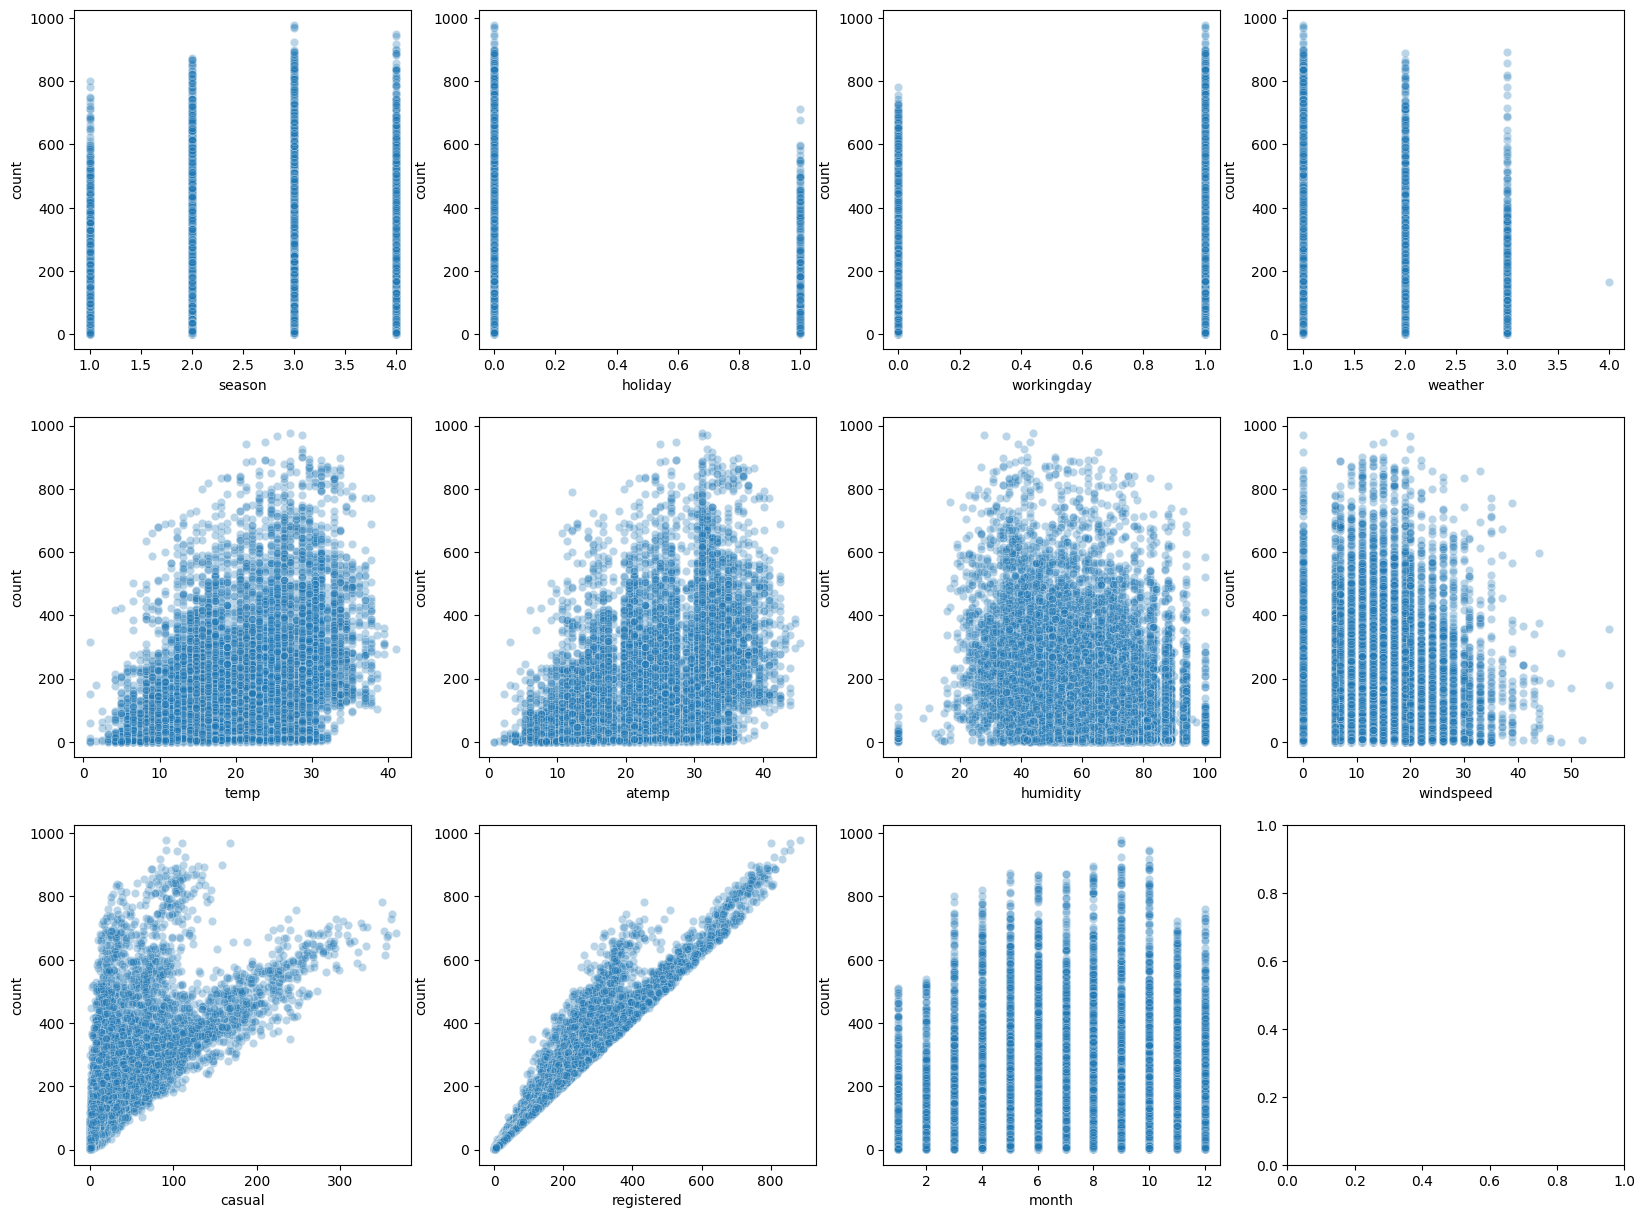

In [77]:
cols_to_plot = df.select_dtypes(include=['number']).columns.drop('count')
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
for idx, feature in enumerate(cols_to_plot):
    sns.scatterplot(data=df, x=feature, y="count", ax=axes[idx // 4, idx % 4], alpha=0.3)
    axes[idx // 4, idx % 4]

### 1. Ответьте на вопросы:

#### Каков характер зависимости числа прокатов от месяца?





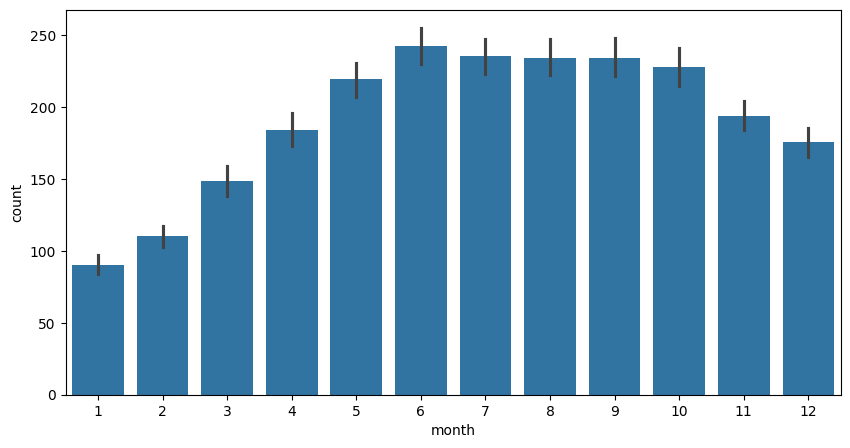

In [78]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='month', y='count')
plt.show()

Ответ: Наибольшее число прокатов приходится на май-октябрь, что, скорее всего, связано с благоприятными условиями для катания по дорогам.

#### Укажите один или два признака, от которых число прокатов скорее всего зависит линейно
_(чем больше значение, тем больше прокатов или наоборот, например)_

Можете проверить результат с помощью lnplot.



Ответ: registered, casual

### 2. Корреляционная матрица

Напомним, что корреляция отражает взаимосвязь двух случайных величин. Она бывает положительная и отрицательная. Чем ближе коэффициент корреляции к нулю, тем меньше взаимосвязь. Чем больше абсолютная корреляци, тем взаимосвязь больше.

Постройте heatmap корреляционной матрицы. Матрица формируется средствами pandas, со стандартным значением параметров.



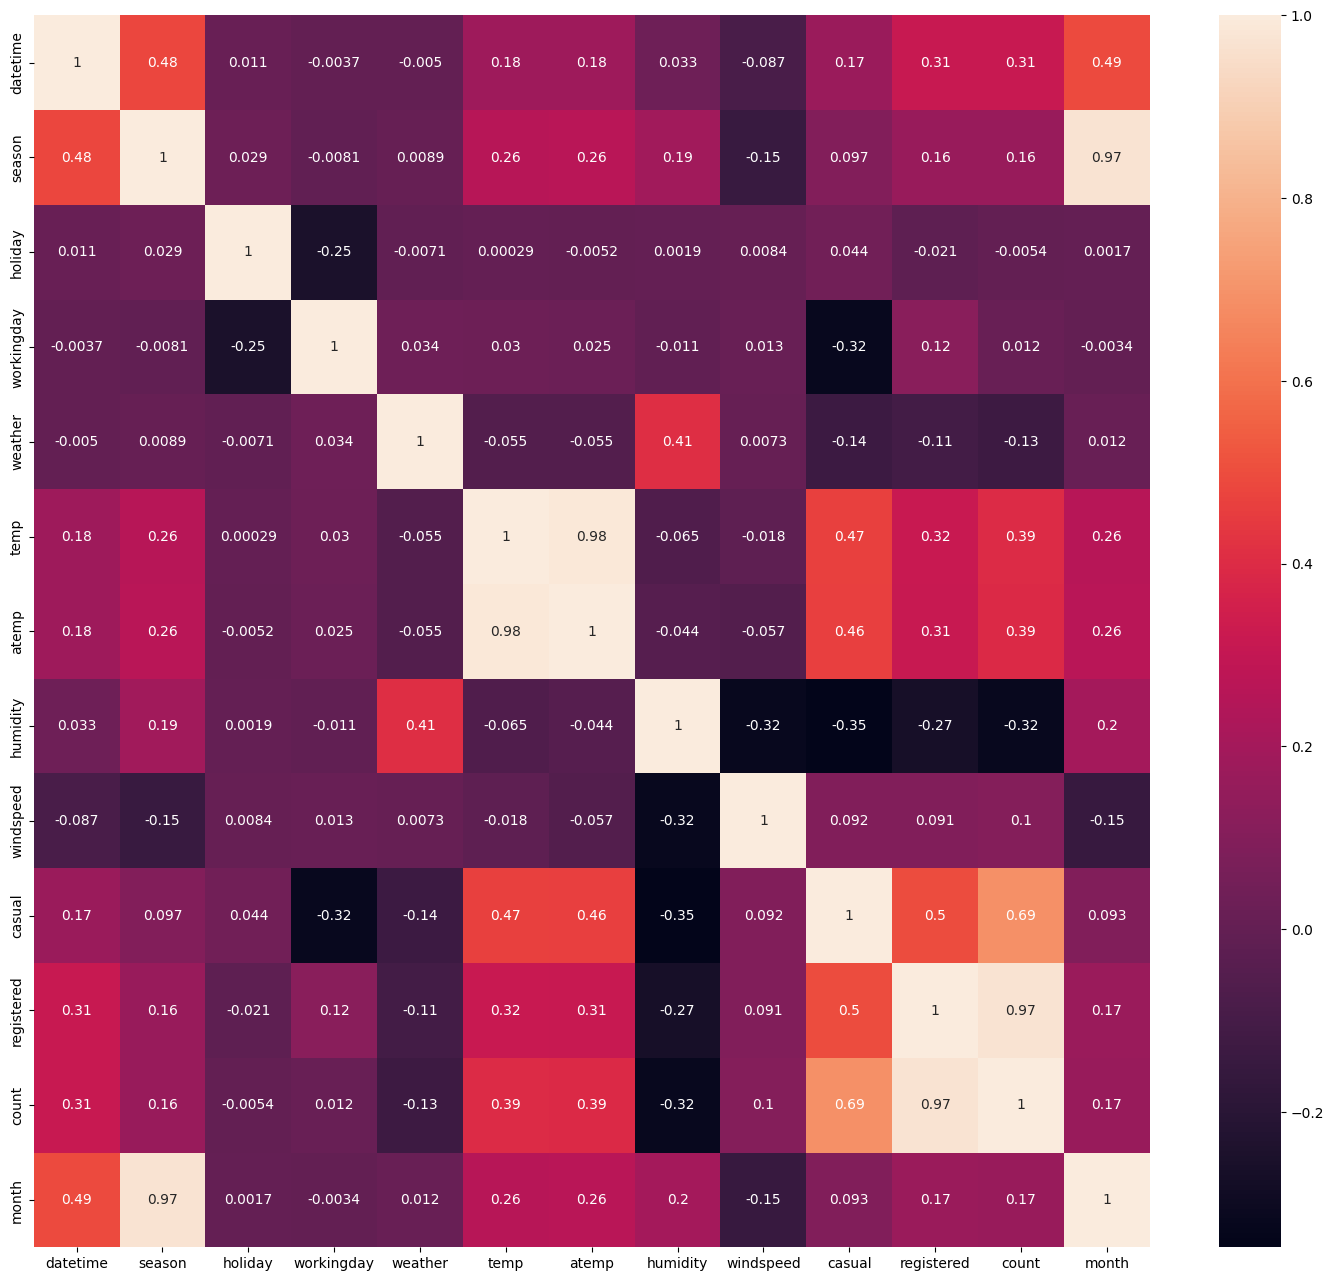

In [79]:
cor_mat = df.corr()
plt.figure(figsize=(18, 16))
sns.heatmap(cor_mat, annot=True)
plt.show()

**Ответьте на вопрос**: с какими признаками количество прокатов коррелирует меньше всего (около 4 штуки). А с какими больше всего?

Ответ:
* меньше всего коррелирует с признаками: holiday, workingday, winspeed, weather;
* больше всего коррелирует с признаками: registered, casual, temp, atemp, humidity

### 3. Barpot

Постройте Bar-график суммарного количества прокатов велосипедов по месяцам за каждый год одновременно. (будет 24 столбика)



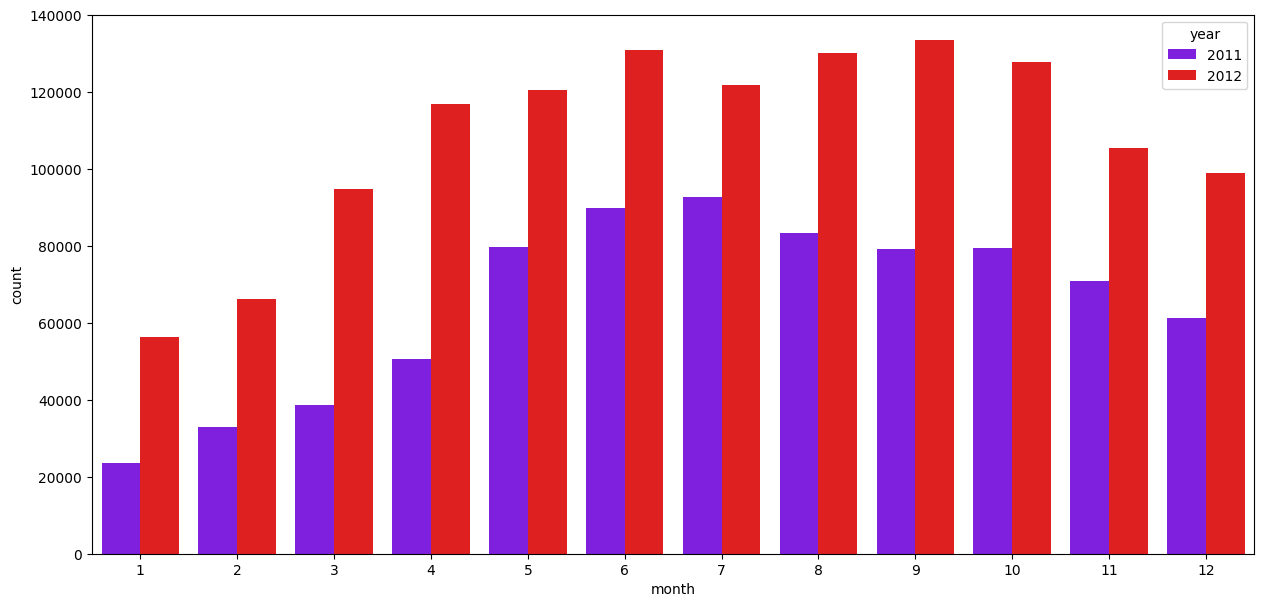

In [80]:
df['year'] = df['datetime'].dt.year

mat = df.groupby(['year', 'month'])['count'].sum().reset_index()
plt.figure(figsize=(15, 7))
sns.barplot(data=mat, x='month', y='count', hue='year', palette='rainbow')
plt.show()

**Ответьте на вопрос:** почему в предыдущем графике была такая большая корреляция между количеством прокатов и годом?

Ответ: возможно компания выросла. Корреляция между registered и сount равна 0,97, что говорит об увеличении числа зарегистрированных пользователей.

### 4. Countplot

Постройте countplot диаграммы для признаков `weekday`, `weathersit`,



/tmp/ipykernel_17774/1567894173.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='weekday', ax=axes[0], palette='rainbow')
/tmp/ipykernel_17774/1567894173.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='weather', ax=axes[1], palette='rainbow')


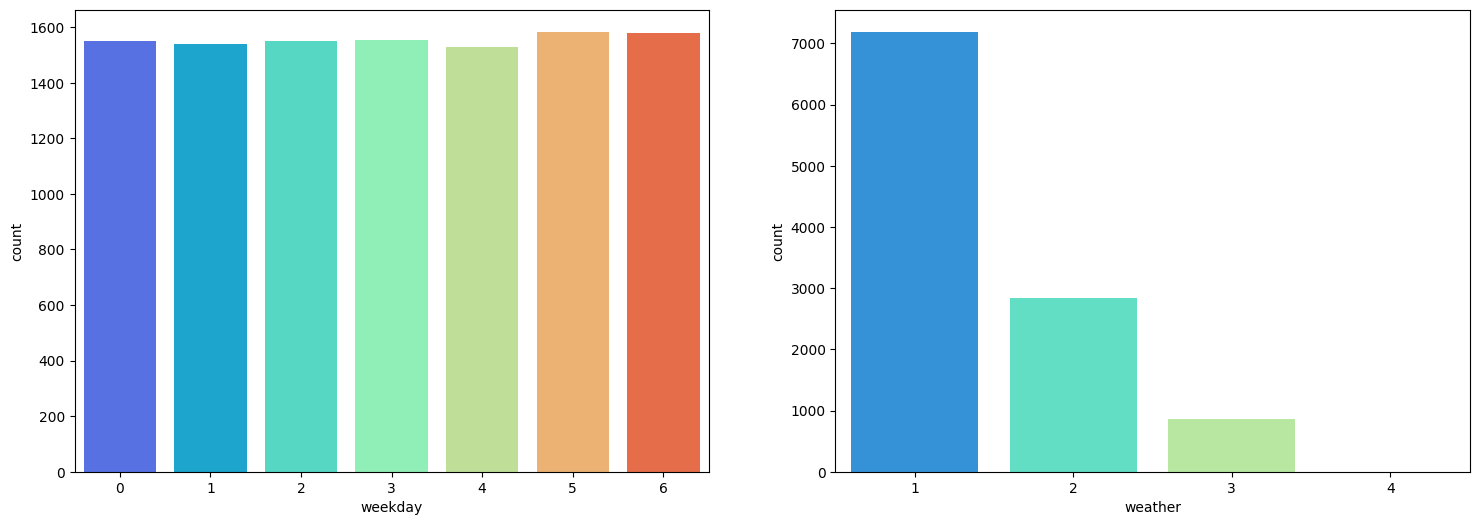

In [81]:
df['weekday'] = df['datetime'].dt.weekday
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
sns.countplot(data=df, x='weekday', ax=axes[0], palette='rainbow')
sns.countplot(data=df, x='weather', ax=axes[1], palette='rainbow')
plt.show()

**Ответьте на вопрос:** что вы можете сказать о том, как формировался этот датасет.



Ответ: про weekday можно сказать, что все столбики почти одинаковы, то есть записи в систему делали каждый час. День недели, видимо, был неважен. Про weather можно сказать, что данные вполне реальны, поскольки самый большой столбец показывает, что люди чаще арендуют велосипеды в хорошую погоду, что звучит логично.

**Ответьте на вопрос:** как называется распределение значений признака `weekday`?

Ответ: равномерное распределение

### 5. Распределение

Постройте распределение целевого признака.


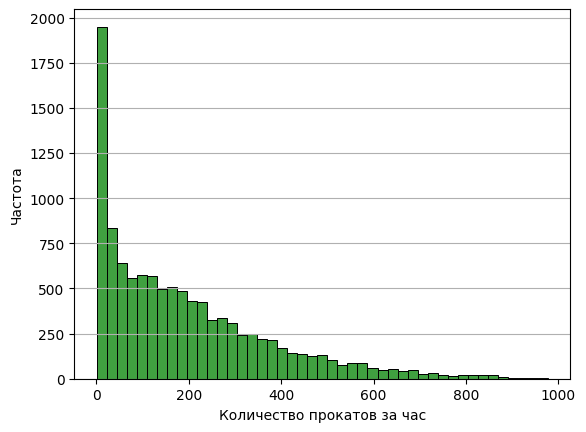

In [82]:
sns.histplot(df['count'], color='green')
plt.xlabel('Количество прокатов за час')
plt.ylabel('Частота')
plt.grid(axis='y')
plt.show()


**Ответьте на вопрос:** основываясь на графике, сколько приблизительно в среднем прокатов бывает в день?

Ответ: приблизительно 150-200 в час прокатов. Если умножить на 24, то получится примерно 3600-4800 прокатов в день

### 6. Совместное распределение признаков

Постройте график совместного распределения признаков температура и ощущение температуры.



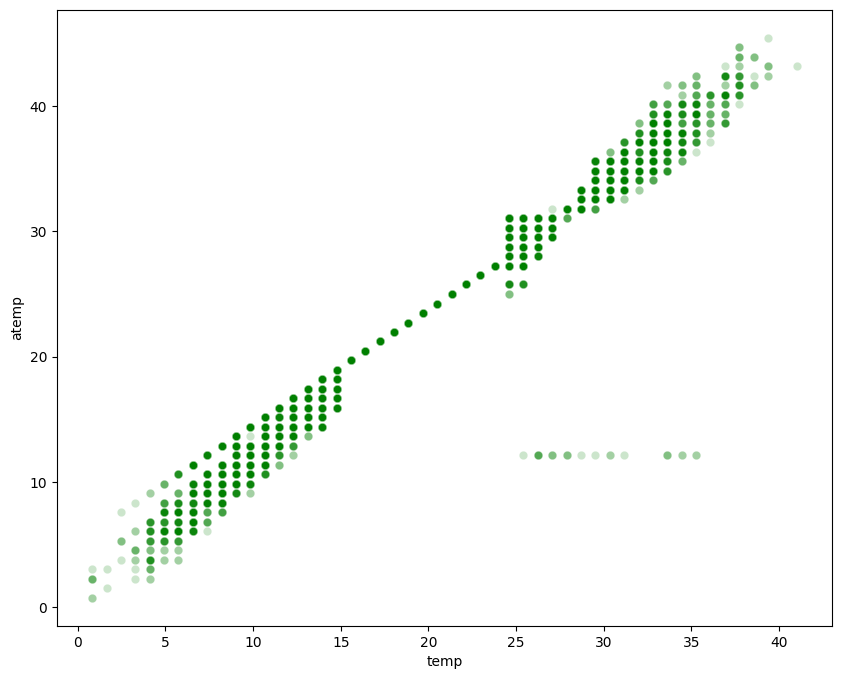

In [89]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='temp', y='atemp', alpha=0.2, color='green')
plt.xlabel('temp')
plt.ylabel('atemp')
plt.show()

In [86]:
error_rows = df[(df['temp'] > 25) & (df['atemp'] < 15)]
print(f"Найдено странных строк: {len(error_rows)}")
error_rows[['temp', 'atemp']]

Найдено странных строк: 24


,temp,atemp
8991,27.88,12.12
8992,27.06,12.12
8993,27.06,12.12
8994,26.24,12.12
8995,26.24,12.12
8996,26.24,12.12
8997,25.42,12.12
8998,26.24,12.12
8999,27.88,12.12
9000,28.70,12.12


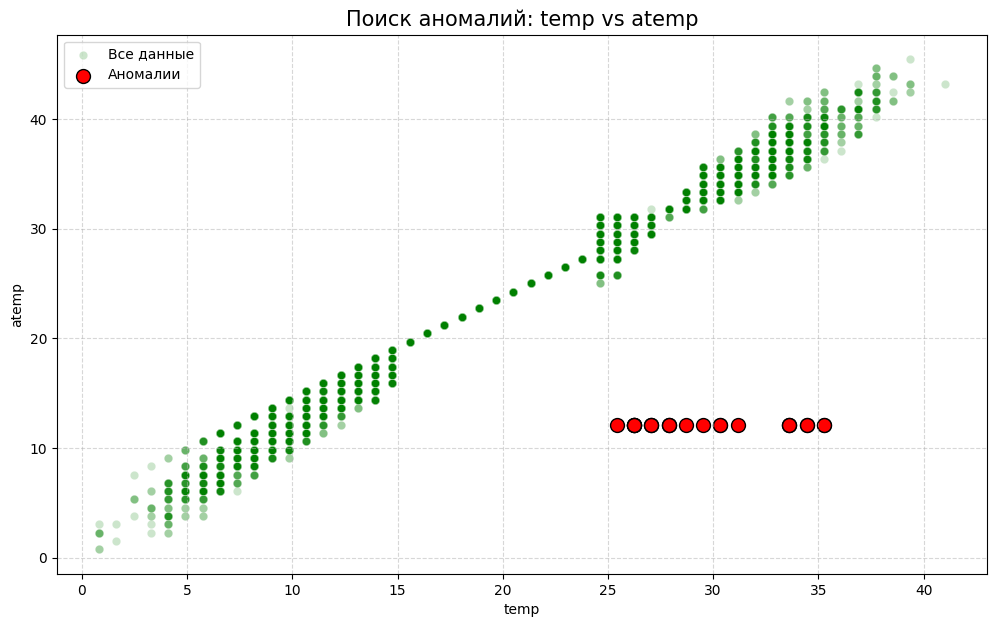

In [90]:
error_index = df[(df['temp'] > 25) & (df['atemp'] < 15)].index
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='temp', y='atemp', alpha=0.2, color='green', label='Все данные')
plt.scatter(df.loc[error_index, 'temp'],
            df.loc[error_index, 'atemp'],
            color='red', s=100, edgecolors='black', label='Аномалии')
plt.title('Поиск аномалий: temp vs atemp', fontsize=15)
plt.xlabel('temp')
plt.ylabel('atemp')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Ответьте на вопрос:** вас в этом графике ничего не настораживает? Почему?

Ответ: существуют аномальные значения, при которых реальная температура соответствует 25-35 градусам, а ощущаемая температура 12 градусов, что трудно объяснить.

### 7. Боксплот (ящик с усами)

Постройте график распределения (боксплот) количества прокатов велосипедов по месяцам в зависимости от того рабочий это день или нет.




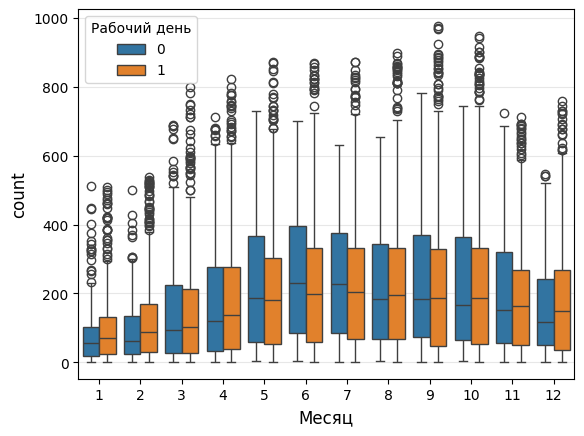

In [18]:
sns.boxplot(data=df, x='month', y='count', hue='workingday')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('count', fontsize=12)
plt.legend(title='Рабочий день')
plt.grid(axis='y', alpha=0.3)

**Ответьте на вопрос:** почему в некоторых месяцах чаще берут велосипеды в будний день, а в некоторые - в выходной.

Ответ: в январе, феврале, декабре количество взятых в аренду велосипедов по будням больше, это может быть связано с тем, что в будни велосипеды используют как транспорт чтобы добраться до работы. А в весенние, летние и осенние месяцы количество

## Комплексное задание №3. Визуальный анализ данных. Часть 2

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
colab = True # если работаете на своём компьютере, в локальной среде, поставьте False
if colab:
    from google.colab import drive
    drive.mount('/content/')

MessageError: Error: credential propagation was unsuccessful

В этом задании Вам предлагается провести визуальный анализ датасета результатов экзаменов студентов  https://www.kaggle.com/spscientist/students-performance-in-exams.

Исходные данные загрузите самостоятельно!

In [21]:
'''if colab:
    df = pd.read_csv('/content/sample_data/StudentsPerformance.csv')
else:
    df = pd.read_csv("../../data/StudentsPerformance.csv")'''

df = pd.read_csv('/content/sample_data/StudentsPerformance.csv')

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Ход задания:

#### 1. Постройте 3 графика, показывающих распределение результатов экзаменов (каждый график на предмет).


Графики должны быть в одном ряду и у них должен быть общий заголовок "Результаты экзаменов".

Для результатов каждого экзамена посчитайте медианные значения.


Медианные значения:
math score: 66.0
reading score: 70.0
writing score: 69.0


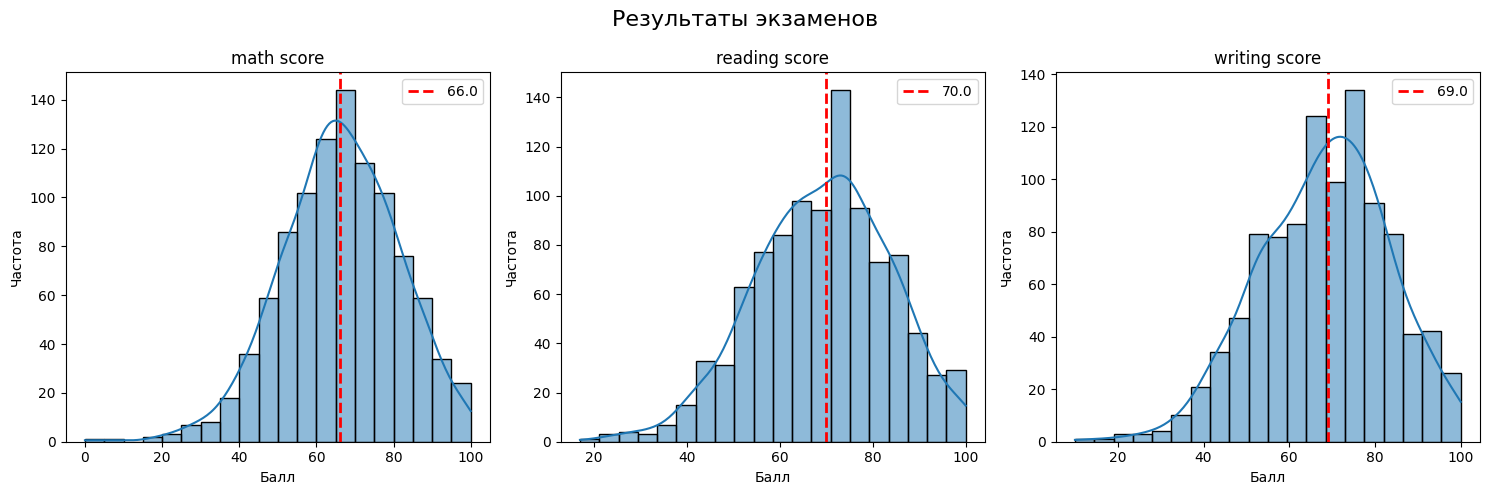

In [22]:
subjects = ['math score', 'reading score', 'writing score']
medians = {subject: df[subject].median() for subject in subjects}
print('Медианные значения:')
for subject, median in medians.items():
  print(f'{subject}: {median:.1f}')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Результаты экзаменов', fontsize=16)
for i, subject in enumerate(subjects):
  ax = axes[i]
  sns.histplot(df[subject], kde=True, ax=ax, bins=20)
  ax.axvline(medians[subject], color='red', linestyle='--', linewidth=2, label=f'{medians[subject]:.1f}')
  ax.set_title(subject)
  ax.set_xlabel('Балл')
  ax.set_ylabel('Частота')
  ax.legend()

plt.tight_layout()
plt.show()

#### 2. Образование родителей
Какие уровни образование есть в столбце *'parental level of education'* и сколько строк в датафрейме соответствует каждому уровню?

Постройте график и ответьте на вопрос ниже

Отличаются ли баллы по математике у детей с разным образованием родителей?
Постройте график, где по оси Х находятся уровни образования родителей, а по У - баллы по математике.


In [23]:
print('Уровни образования и количество строк:\n', df['parental level of education'].value_counts())

Уровни образования и количество строк:
 parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


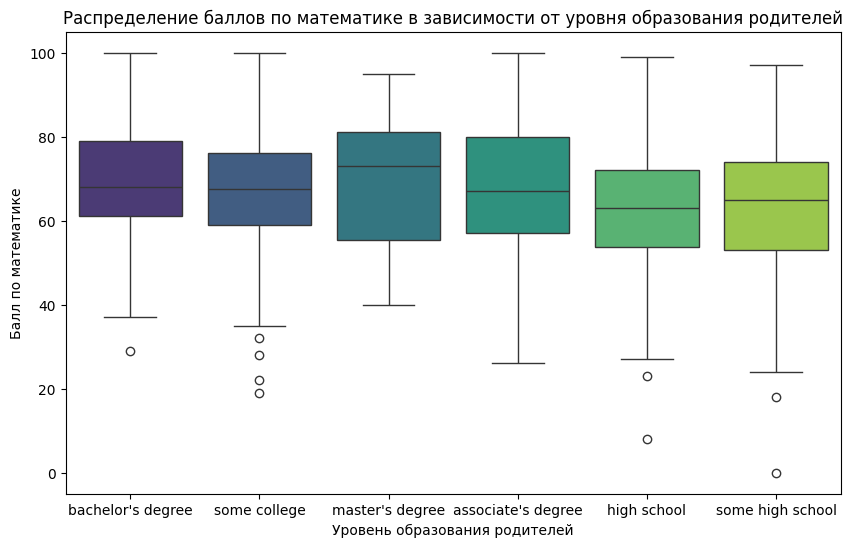

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='parental level of education', y='math score', hue='parental level of education', palette='viridis')
plt.title('Распределение баллов по математике в зависимости от уровня образования родителей')
plt.xlabel('Уровень образования родителей')
plt.ylabel('Балл по математике')
plt.show()

#### 3. Выведите число студенток, набравших больше 90 баллов по всем предметам.


In [27]:
girls_count = df[(df['gender'] == 'female') &
 (df['math score'] > 90) &
  (df['reading score'] > 90) &
   (df['writing score'] > 90)]
print('Число студенток, набравших больше 90 баллов по всем предметам:', len(girls_count))
girls_count

Число студенток, набравших больше 90 баллов по всем предметам: 17


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
114,female,group E,bachelor's degree,standard,completed,99,100,100
165,female,group C,bachelor's degree,standard,completed,96,100,100
179,female,group D,some high school,standard,completed,97,100,100
451,female,group E,some college,standard,none,100,92,97
458,female,group E,bachelor's degree,standard,none,100,100,100
546,female,group A,some high school,standard,completed,92,100,97
566,female,group E,bachelor's degree,free/reduced,completed,92,100,100
594,female,group C,bachelor's degree,standard,completed,92,100,99
685,female,group E,master's degree,standard,completed,94,99,100
712,female,group D,some college,standard,none,98,100,99


#### 4. Сравните баллы у студентов разных полов. Используя agg() выведите минимальное, максимальное и медианное значение


In [28]:
print('Сравнение баллов студентов по полу')
df.groupby('gender')[['math score', 'reading score', 'writing score']].agg(['min', 'max', 'median'])

Сравнение баллов студентов по полу


math score             reading score             writing score       \
              min  max median           min  max median           min  max   
gender                                                                       
female          0  100   65.0            17  100   73.0            10  100   
male           27  100   69.0            23  100   66.0            15  100   

               
       median  
gender         
female   74.0  
male     64.0

#### 5. Выясните, влияет ли обед и подготовка к тесту на средний балл студентов разного пола
###### (подсказка: используете  [pd.agg()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.agg.html))

In [29]:
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

df.groupby(['gender', 'lunch', 'test preparation course'])[['average_score']].mean()

average_score
gender lunch        test preparation course               
female free/reduced completed                    69.528571
                    none                         59.501401
       standard     completed                    77.479532
                    none                         70.961240
male   free/reduced completed                    65.721311
                    none                         58.323810
       standard     completed                    73.513274
                    none                         65.486043

#### 6. Постройте график, показывающий зависимость уровня образования родителей от их расы

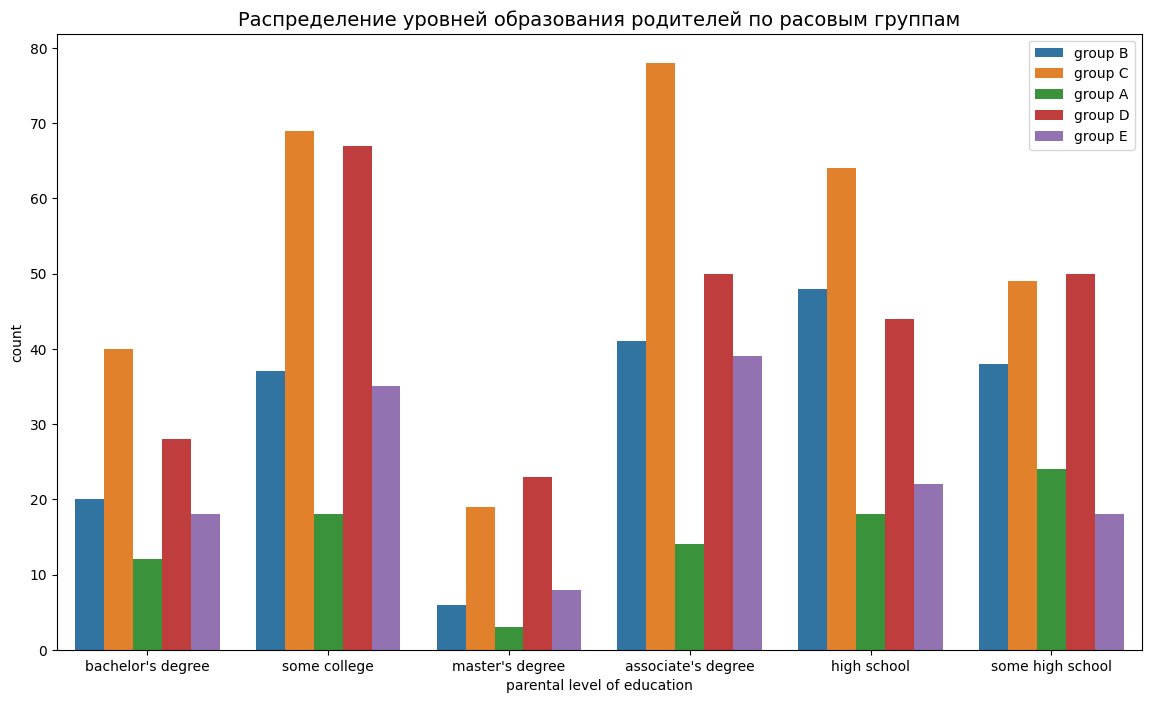

In [30]:
plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='parental level of education', hue='race/ethnicity')
plt.title('Распределение уровней образования родителей по расовым группам', fontsize=14)
plt.legend()
plt.show()

#### 7. Постройте график, показывающий зависимость прохождения подготовительного теста от уровня образования родителей.


Кто чаще ходит на курсы: дети, родители которых закончили только старшую школу, или дети, чьи родители получили степень бакалавра\магистра?

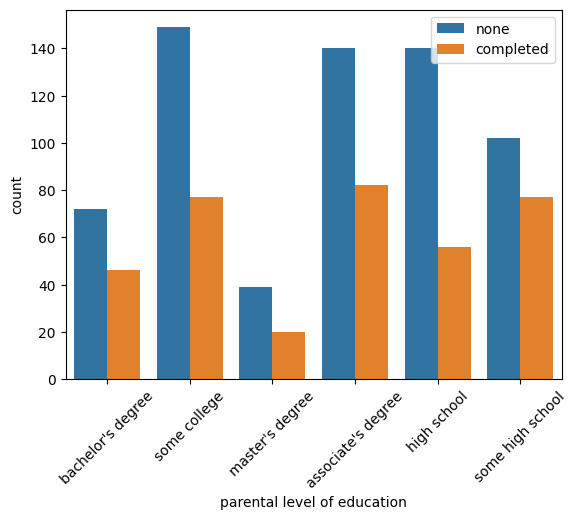

In [31]:
sns.countplot(data=df, x='parental level of education', hue='test preparation course')
plt.xticks(rotation=45)
plt.legend()
plt.show()

#### 8. Постройте plot.pie, показывающий, сколько людей сдали\не сдали экзамен по математике.

Сдавшим считается человек, набравший 40 баллов.

###### Подсказка: создайте столбец в датафрейме, который содержит результат сдачи (сдал или не сдал)

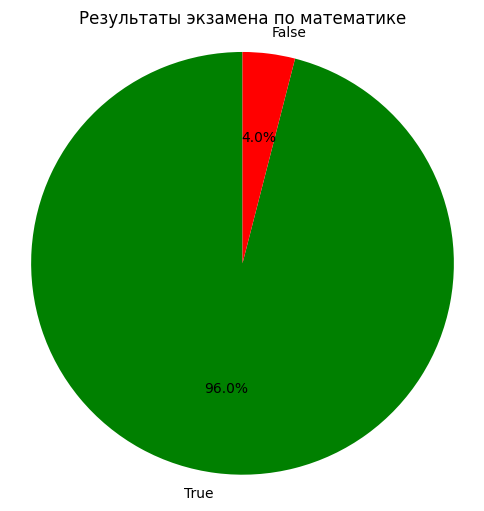

In [33]:
df['math_passed'] = df['math score'] >= 40
math_counts = df['math_passed'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(math_counts, labels=math_counts.index, autopct='%1.1f%%', startangle=90, colors=['green', 'red'])
plt.title('Результаты экзамена по математике')
plt.axis('equal')
plt.show()

#### 9. Постройте plot.pie, показывающий распределение студентов по оценкам

Оценки студентов выставляются по шкале:<br>
0  - 40 marks : grade E<br>
41 - 60 marks : grade D<br>
60 - 70 marks : grade C<br>
70 - 80 marks : grade B<br>
80 - 90 marks : grade A<br>
90 - 100 marks : grade O<br>

Для этого посчитайте сумму результатов за 3 экзамена и найдите среднее. Оценка выставляется по среднему значению. Если студент не сдал математику(даже если средний балл выше 40), он получает Е

/tmp/ipykernel_17774/985732842.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='grade', data=df, order=order, palette='rainbow')


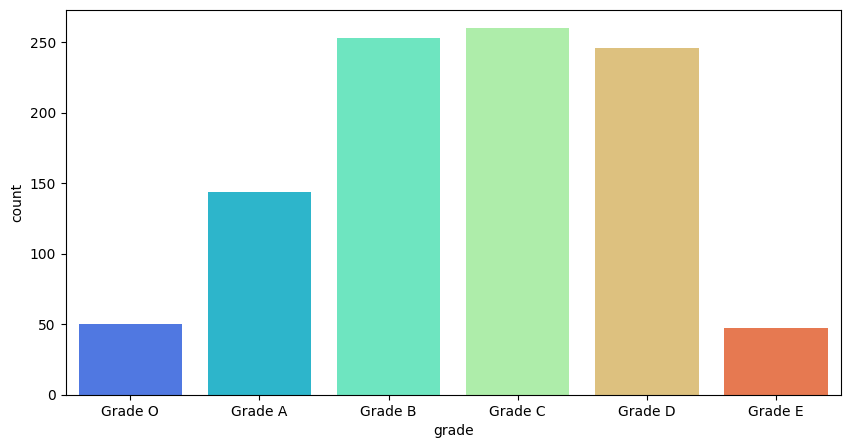

In [37]:
df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
df['grade'] = 'Grade E'
df.loc[(df['average_score'] > 40) & (df['math score'] >= 40), 'grade'] = 'Grade D'
df.loc[(df['average_score'] > 60) & (df['math score'] >= 40), 'grade'] = 'Grade C'
df.loc[(df['average_score'] > 70) & (df['math score'] >= 40), 'grade'] = 'Grade B'
df.loc[(df['average_score'] > 80) & (df['math score'] >= 40), 'grade'] = 'Grade A'
df.loc[(df['average_score'] > 90) & (df['math score'] >= 40), 'grade'] = 'Grade O'

plt.figure(figsize=(10, 5))
order = ['Grade O', 'Grade A', 'Grade B', 'Grade C', 'Grade D', 'Grade E']
sns.countplot(x='grade', data=df, order=order, palette='rainbow')
plt.show()

#### 10. Постройте countplot, показывающий зависимость между итоговой оценкой студентов и его полом. Студенты какого пола получили больше оценок О, А, В

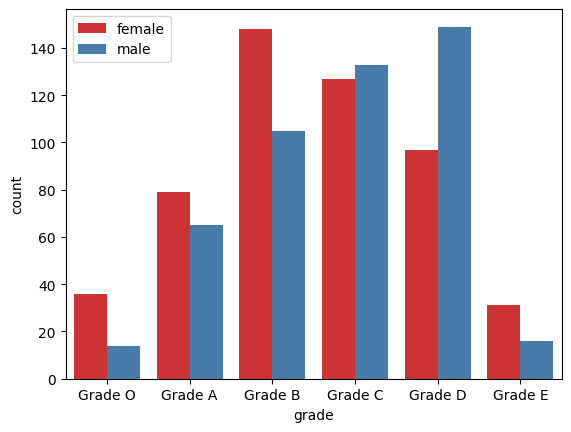

In [38]:
sns.countplot(x='grade', hue='gender', data=df, order=order, palette='Set1')
plt.legend()
plt.show()